# Diffusion vs. SGD training

## Initialisation

### Imports

In [14]:
import os
import gc
os.environ["MKL_THREADING_LAYER"] = "GNU"

import matplotlib
matplotlib.use('Agg')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Create output directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Imports done.")

Imports done.


### Diffusion Settings

In [15]:
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    emb_factor = np.log(10000) / (half_dim - 1)
    emb_factor = torch.tensor(emb_factor, device=timesteps.device, dtype=torch.float32)
    emb = torch.arange(half_dim, device=timesteps.device, dtype=torch.float32)
    emb = torch.exp(-emb * emb_factor)
    emb = timesteps.float().unsqueeze(1) * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros(timesteps.size(0), 1, device=timesteps.device)], dim=1)
    return emb

In [16]:
T = 100  # Number of diffusion steps
betas = torch.linspace(1e-4, 0.02, T, dtype=torch.float32)
alphas = 1 - betas
# Set the device (use GPU if available).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
alpha_bars = torch.cumprod(alphas, dim=0).to(device) # noise level schedule

Using device: cuda


In [17]:
cond_dim = 1 
target_dim = 1
time_emb_dim = 16 

## Architectures

### MLP

Desgin rationale:
- LayerNorm normalise activations per sample instead of per batch, hopefully making the training more stable
- GELU is smoother than ReLu. GELU also converges better on regression, while ReLU might lead to a dead nuron
- diffusion mode input is `[x, y_noisy, time_emb]`, SGD mode input is `x` (dim=1).

In [18]:
class MLP(nn.Module):
    def __init__(self, diffusion=True, hidden_units=128, n_layers=4):
        super().__init__()
        self.diffusion = diffusion
        input_dim = cond_dim + target_dim + time_emb_dim if diffusion else cond_dim
        layers = []
        for _ in range(n_layers):
            layers.append(nn.Linear(input_dim, hidden_units))
            layers.append(nn.LayerNorm(hidden_units)) # stablise training
            # layers.append(nn.ReLU())
            layers.append(nn.GELU())
            input_dim = hidden_units
        layers.append(nn.Linear(hidden_units, target_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x, y=None, t=None):
        if self.diffusion:
            time_emb = get_timestep_embedding(t, time_emb_dim) # b, 16
            x = torch.cat([x, y, time_emb], dim=1)  # B, 1+1+16
        return self.net(x)

### 1D-CNN

**Design rationale:** 
- 3 blocks of conv + BatchNorm + ReLU, with increasing filters (32, 64, 128), and then global avg pooling and a linear head.
- batchNorm normalise across bacthes per channel. this works because the batch size (256) is large enough to be stable. batchNorm also allows higher learning rates. 
- diffusion mode input has 18 channels `(x+y_noisy+time_emb)`, SGD mode has 1 channel. 

In [19]:
class CNN1D(nn.Module):
    def __init__(self, diffusion=True):
        super().__init__()
        self.diffusion = diffusion
        input_channels = cond_dim + target_dim + time_emb_dim if diffusion else cond_dim
        
        self.conv_blocks = nn.Sequential( # each keep 1-length sequence w/ kernel=1
            # nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            # nn.ReLU(),
            # nn.Conv1d(32, 64, kernel_size=3, padding=1),
            # nn.ReLU(),
            # nn.Conv1d(64, 128, kernel_size=3, padding=1),
            # nn.ReLU()
            nn.Conv1d(input_channels, 32, kernel_size=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1) # -> B, 128, 1
        self.fc = nn.Linear(128, target_dim)

    def forward(self, x, y=None, t=None):
        if self.diffusion:
            time_emb = get_timestep_embedding(t, time_emb_dim) # B, 16
            x = torch.cat([x, y, time_emb], dim=1) # B, 16+1+1
        x = x.unsqueeze(-1) # B, C, 1
        x = self.conv_blocks(x) # B, 128, 1
        x = self.pool(x).squeeze(-1) #  B, 128
        return self.fc(x)

### Transformer

**Design rationale:** 
- architecture is linear embedding layer that map inputs to 64-dim, then 2 encoder layers with 4 attention heads. 
- input is 18-dim in diffusion mode, projectecd to 64-dim, then get treated as a single token sequence.
- the raw input need to be treated to fit the 64 dimension of the transformer bfr applying attention, othrwise the dot oproduct of the attentio would ended up getting computed in a very low dim.
- dropout=0.1 should be sufficient since small amount of dropout regulerise the attntion weights without restricting convergence

In [20]:
class TransformerModel(nn.Module):
    def __init__(self, diffusion=True, d_model=64, nhead=4, num_layers=2, dim_feedforward=128):
        super().__init__()
        self.diffusion = diffusion
        input_dim = cond_dim + target_dim + time_emb_dim if diffusion else cond_dim
                
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            dropout=0.1, 
            batch_first=True, # B, seq, dmodel
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, target_dim)
    
    def forward(self, x, y=None, t=None):
        if self.diffusion:
            time_emb = get_timestep_embedding(t, time_emb_dim) # B, 16
            x = torch.cat([x, y, time_emb], dim=1) # B, 18
        x = self.embedding(x).unsqueeze(1) # B, dmodel -> B, 1, dmodel
        x = self.encoder(x).squeeze(1) # -> B, dmodel
        return self.fc_out(x)

## Training Methods

### Diffusion Training

In [21]:
def train_diffusion(model, dataloader, optimizer, n_epochs=5, device="cpu"):
    mse_loss = nn.MSELoss()
    model.train()
    loss_history = []

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for batch in dataloader:
        # for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            x, y = batch
            x, y = x.to(device), y.to(device) # B, 1 (each)
            batch_size = x.size(0) 
            t = torch.randint(0, T, (batch_size,), device=device) # rnadom timestep for each sample
            alpha_bar_t = alpha_bars[t].unsqueeze(1) # retrieve noiselvl for each t
            noise = torch.randn_like(y) # random noise
            y_noisy = torch.sqrt(alpha_bar_t) * y + torch.sqrt(1-alpha_bar_t) * noise # forward diffussion 
            
            optimizer.zero_grad()
            pred_noise = model(x, y_noisy, t)
            loss = mse_loss(pred_noise, noise)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * batch_size
        
        avg_epoch_loss = epoch_loss / len(dataloader.dataset)
        loss_history.append(avg_epoch_loss)
        # print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_epoch_loss:.4f}")

        if device.type == 'cuda':
            torch.cuda.empty_cache()
            gc.collect()
    
    return loss_history

### Reverse Diffusion (Sampling)

In [22]:
@torch.no_grad()
def sample_diffusion(model, cond, device="cpu"):
    """
    Given the condition input, reverse the diffusion process to generate a sample target.
    """
    model.eval()
    batch_size = cond.size(0)
    noisy_target = torch.randn(batch_size, 1, device=device)
    
    for t_int in reversed(range(T)):
        t = torch.full((batch_size,), t_int, device=device, dtype=torch.long)
        alpha_bar_t = alpha_bars[t_int].to(device)
        beta_t = betas[t_int].to(device)
        alpha_t = alphas[t_int].to(device)

        alpha_bar_t = alpha_bar_t.view(1, 1)
        beta_t = beta_t.view(1, 1)
        alpha_t = alpha_t.view(1, 1)

        eps_pred = model(cond, noisy_target, t) # predict noise at t
        noise = torch.randn_like(noisy_target) if t_int > 0 else 0.0
        # reverse step of DDPM
        noisy_target = (1 / torch.sqrt(alpha_t)) * (noisy_target - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_pred) \
                       + torch.sqrt(beta_t) * noise
    
    return noisy_target

### SGD Training & Inference

In [23]:
def train_sgd(model, dataloader, optimizer, n_epochs=5, device="cpu"):
    model.train()
    criterion = nn.MSELoss()
    loss_history = []

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for batch in dataloader:
        # for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            x, y = batch
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(x) # B, 1
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x.size(0)

        avg_epoch_loss = epoch_loss / len(dataloader.dataset)
        loss_history.append(avg_epoch_loss)
        # print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_epoch_loss:.4f}")

    return loss_history

In [24]:
@torch.no_grad()
def test_sgd(model, cond, device="cpu"):
    """Run deterministic inference for the SGD model."""
    model.eval()
    pred = model(cond)
    return pred

## Training

In [25]:
X_train = np.load('circles_data/X_train.npy').astype(np.float32)
Y_train = np.load('circles_data/Y_train.npy').astype(np.float32)
X_test = np.load('circles_data/X_test.npy').astype(np.float32)

dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
batch_size = 256 # i tried 64 but slower
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

In [36]:
n_epochs = 50
all_loss_histories = {} 
models = [
    ('MLP', MLP(diffusion=False), MLP(diffusion=True)),
    ('CNN1D', CNN1D(diffusion=False), CNN1D(diffusion=True)),
    ('Transformer', TransformerModel(diffusion=False), TransformerModel(diffusion=True)),
]

for name, sgd_model, diff_model in models:
    print(f"\n=== Training {name} ===")

    # SGD training
    print("\nTraining SGD version...")
    sgd_model.to(device)
    optimizer = optim.Adam(sgd_model.parameters(), lr=1e-3)
    sgd_hist = train_sgd(sgd_model, dataloader, optimizer, n_epochs, device)

    torch.save(sgd_model.state_dict(), f'models/{name}_sgd.pth')
    all_loss_histories[f'{name}_sgd'] = sgd_hist

    # diffusion training
    print("\nTraining Diffusion version...")
    diff_model.to(device)
    optimizer = optim.Adam(diff_model.parameters(), lr=1e-3)
    diff_hist = train_diffusion(diff_model, dataloader, optimizer, n_epochs, device)

    torch.save(diff_model.state_dict(), f'models/{name}_diffusion.pth')
    all_loss_histories[f'{name}_diffusion'] = diff_hist

print("\n=== All training complete ===")


=== Training MLP ===

Training SGD version...

Training Diffusion version...

=== Training CNN1D ===

Training SGD version...

Training Diffusion version...

=== Training Transformer ===

Training SGD version...

Training Diffusion version...

=== All training complete ===


## Training Loss Curves

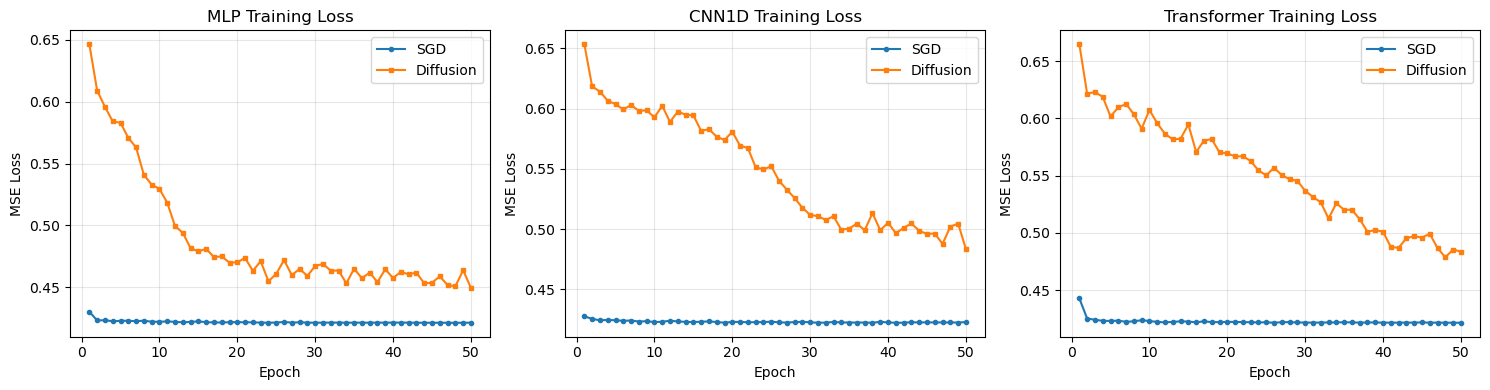

Loss curves saved.


In [37]:
%matplotlib inline

model_names = ['MLP', 'CNN1D', 'Transformer']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, model_names):
    sgd_hist  = all_loss_histories[f'{name}_sgd']
    diff_hist = all_loss_histories[f'{name}_diffusion']
    epochs = range(1, len(sgd_hist) + 1)
    ax.plot(epochs, sgd_hist,  label='SGD',      marker='o', ms=3)
    ax.plot(epochs, diff_hist, label='Diffusion', marker='s', ms=3)
    ax.set_title(f'{name} Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/loss_curves.png', dpi=100)
plt.show()
print("Loss curves saved.")

## Prediction Visualisation


=== Testing MLP ===


C:\Users\User\AppData\Local\Temp\ipykernel_22864\3827593367.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f'models/{name}_sgd.pth', map_locati

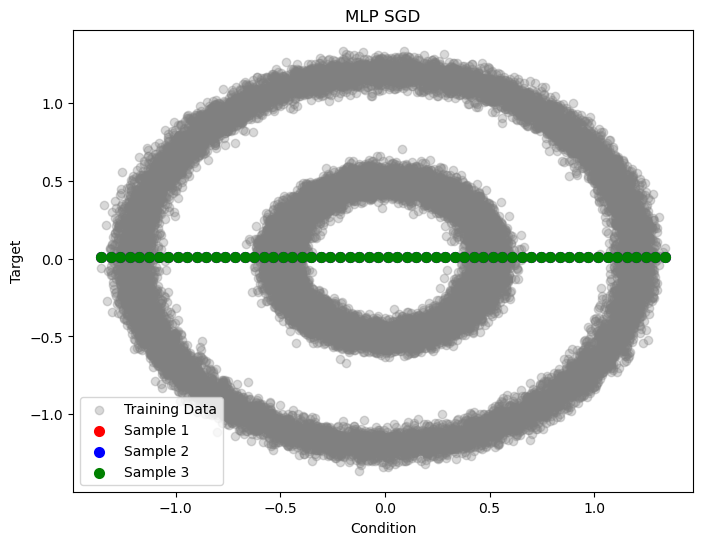

C:\Users\User\AppData\Local\Temp\ipykernel_22864\3827593367.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f'models/{name}_diffusion.pth', map_

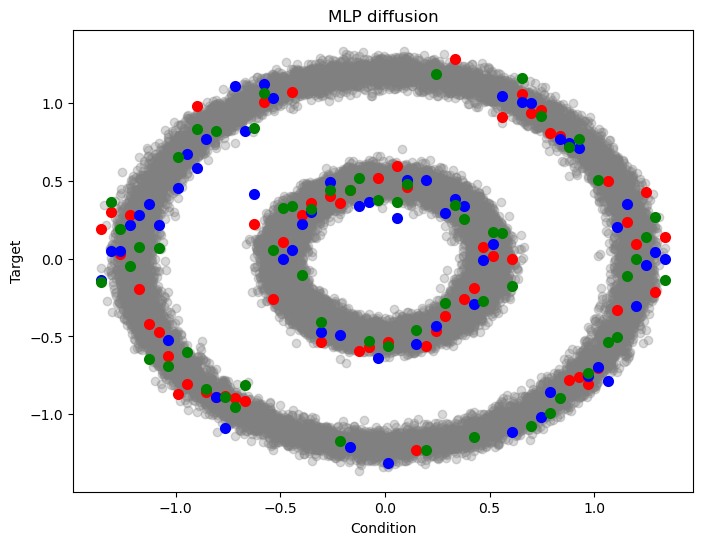


=== Testing CNN1D ===


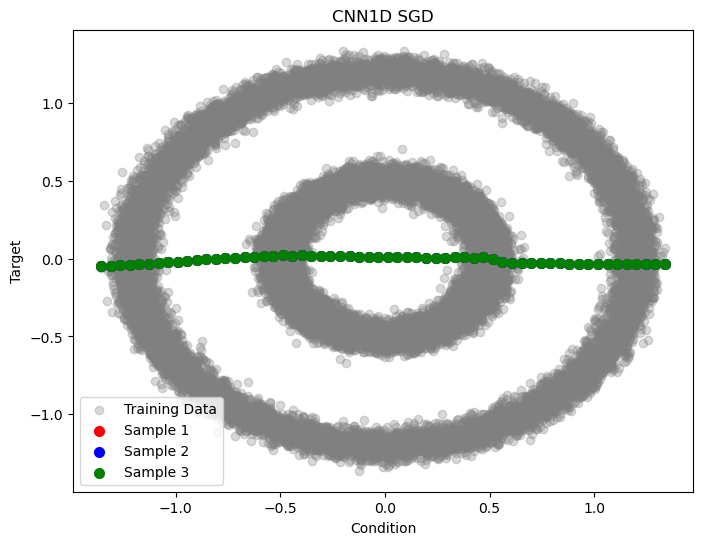

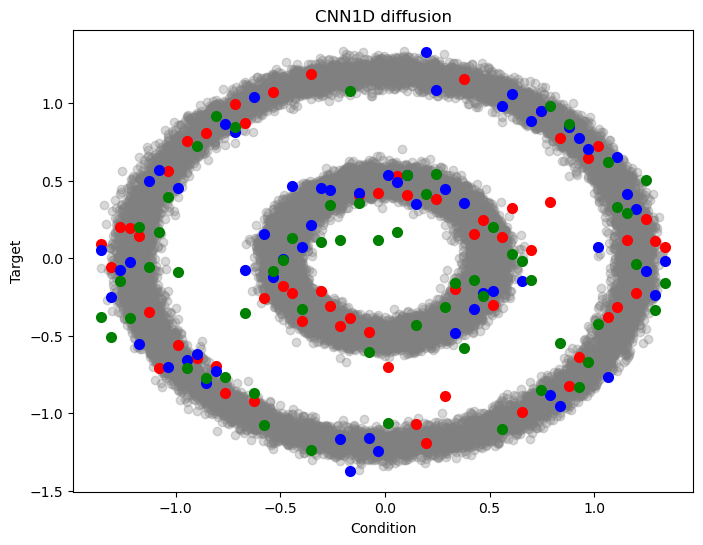


=== Testing Transformer ===


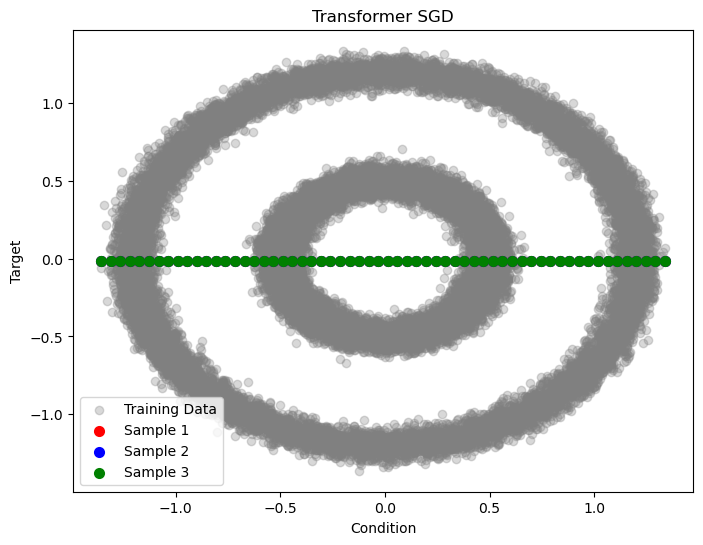

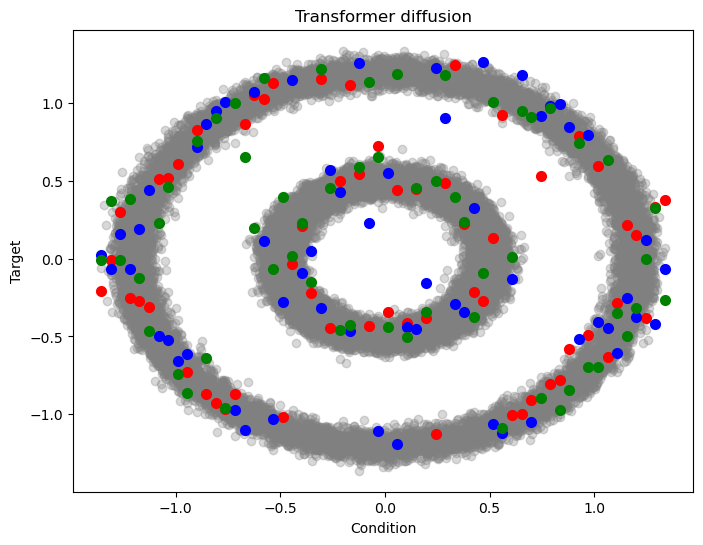

In [38]:
%matplotlib inline
# generate samples for a range of condition values.
X_train = np.load('circles_data/X_train.npy')
Y_train = np.load('circles_data/Y_train.npy')
x_test = np.load('circles_data/X_test.npy')
x_test_tensor = torch.from_numpy(x_test).to(device)

# load model
models = [
        ('MLP', MLP(diffusion=False), MLP(diffusion=True)),
        ('CNN1D', CNN1D(diffusion=False), CNN1D(diffusion=True)),
        ('Transformer', TransformerModel(diffusion=False), TransformerModel(diffusion=True))
    ]

n_samples = 3  # n of sample curves to generate.

for name, sgd_model, diff_model in models:
    print(f"\n=== Testing {name} ===")

    sgd_model = sgd_model.to(device)
    state_dict = torch.load(f'models/{name}_sgd.pth', map_location=device)
    sgd_model.load_state_dict(state_dict)

    all_x = []
    all_y = []
    with torch.no_grad():
        for _ in range(n_samples):
            sample_target = test_sgd(sgd_model, x_test_tensor, device=device)
            all_x.append(x_test)   
            all_y.append(sample_target.cpu().numpy())

    # Visualization: Plot the training (transformed) data and the generated samples.
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train, Y_train, color='gray', alpha=0.3, label='Training Data')
    colors = ['red', 'blue', 'green']
    for i in range(n_samples):
        plt.scatter(all_x[i], all_y[i], color=colors[i], lw=2, label=f'Sample {i+1}')
    plt.xlabel("Condition")
    plt.ylabel("Target")
    plt.title(f"{name} SGD")
    plt.legend()
    plt.show()

    diff_model = diff_model.to(device)
    state_dict = torch.load(f'models/{name}_diffusion.pth', map_location=device)
    diff_model.load_state_dict(state_dict)

    all_x = []
    all_y = []
    with torch.no_grad():
        for _ in range(n_samples):
            sample_target = sample_diffusion(diff_model, x_test_tensor, device=device)
            all_x.append(x_test)   
            all_y.append(sample_target.cpu().numpy())

    # Visualization: Plot the training (transformed) data and the generated samples.
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train, Y_train, color='gray', alpha=0.3, label='Training Data')
    colors = ['red', 'blue', 'green']
    for i in range(n_samples):
        plt.scatter(all_x[i], all_y[i], color=colors[i], lw=2, label=f'Sample {i+1}')
    plt.xlabel("Condition")
    plt.ylabel("Target")
    plt.title(f"{name} diffusion")
    # plt.legend()
    plt.show()

# results_dir = os.path.join(cwd, "results")
# os.makedirs(results_dir, exist_ok=True)
# fig_filename = os.path.join(results_dir, "MLP_diffusion_results_S.png")
# plt.savefig(fig_filename, dpi=100)
# plt.close()  # Free the figure.
# print("Figure successfully saved as:", fig_filename)

## Analysis and Discussion


### SGD vs. Diffusion Comparison

SGD does a deterministic mapping of x to y. Because of the concentric circles dataset is multi-modal (i.e. an x value corresponds to two possible y values), the SGD model is forced to collapse to a single prediction (i.e. the mean) which can be between the two rings in a region where the actual data density is low. This is the main limitation of MSE regression when facing multi-modal targets.

Diffusion treats target generation as a random/stochastic process. The model learns noise distribution, then during reverse sampling, different rand.seeds produce different possible y values. Running 3 samples of the same x shows how the diffusion model can recover both outer and inner rings, reflecting the the shape of the data correctly.

SGD training's loss drop early and then flatten, while diffusion loss decreases gradually since predicting noise at random timesteps is a way harder task. We do have to note that both the diffusion loss and SGD MSE is not comparable at all, since they measure different things (noise pred error and regression error).

Conclusion, SGD is more simple and effecient enough for non multi-modal target SGD, but for multi-modal distributions like our concentric circles data, diffusion models are much better at preserving the stochasticity in its output.